# Laboratorio 2 — Complejidad y búsqueda de hiperparámetros (AlpesHearth)

Este notebook está construido **siguiendo el estilo del Lab 1 entregado** (limpieza + preprocesamiento con `ColumnTransformer`) y las **actividades de práctica** (regresión lineal/polinomial/regularizada).  
Cubre explícitamente las actividades 1–7 del enunciado del Laboratorio 2.

**Entrega:** Notebook ejecutado + video (máx. 3 min).

## 0. Setup

In [ ]:
import pandas as pd
import numpy as np
import re

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler, PolynomialFeatures
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)

RANDOM_STATE = 42
TEST_SIZE = 0.25

TARGET = "CVD Risk Score"
AUX_LABEL = "CVD Risk Level"   

## 1. Carga de datos (igual que en el Lab 1)

In [2]:
def read_csv_auto_sep(path: str) -> pd.DataFrame:
    # Detecta separador por primera línea
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        first_line = f.readline()
    sep = ";" if first_line.count(";") > first_line.count(",") else ","
    return pd.read_csv(path, sep=sep)

train_path = "data/Datos Lab 1.csv"
test_path = "data/Datos Test Lab 1.csv"
dicc_path = "data/DiccPacientes.xlsx"

train_raw = read_csv_auto_sep(train_path)
test_raw  = read_csv_auto_sep(test_path)
dicc_raw  = pd.read_excel(dicc_path)

# Limpieza básica de nombres de columnas
train_raw.columns = train_raw.columns.str.strip()
test_raw.columns  = test_raw.columns.str.strip()
dicc_raw.columns  = dicc_raw.columns.str.strip()

print("Train shape:", train_raw.shape)
print("Test  shape:", test_raw.shape)
display(dicc_raw.head(10))

print("Columnas extra en train (vs test):", sorted(list(set(train_raw.columns) - set(test_raw.columns))))

Train shape: (1639, 24)
Test  shape: (194, 22)


,Nombre Columna,Tipo de dato,Comentarios
0,Patient ID,String,Identificador del paciente
1,Date of Service,Date,Fecha de la atención
2,Sex,String,"Sexo (Femenino, Masculino)"
3,Age,Integer,Edad
4,Weight (kg),Float,Peso
5,Height (m),Float,Altura
6,BMI,Float,Índice de masa corporal
7,Abdominal Circumference (cm),Float,Circunferencia abdominal
8,Blood Pressure (mmHg),String,"Presión sanguínea, de la forma ""<Presión arter..."
9,Total Cholesterol (mg/dL),Float,Colesterol total


Columnas extra en train (vs test): ['CVD Risk Level', 'CVD Risk Score']


## 2. Limpieza y normalización

In [3]:
CAT_COLS = [
    "Sex",
    "Smoking Status",
    "Diabetes Status",
    "Physical Activity Level",
    "Family History of CVD",
    "Blood Pressure Category",
]

def parse_bp_series(series: pd.Series):
    sys_vals, dia_vals = [], []
    for v in series.astype(str):
        m = re.match(r"^\s*(\d+)\s*/\s*(\d+)\s*$", v)
        if m:
            sys_vals.append(float(m.group(1)))
            dia_vals.append(float(m.group(2)))
        else:
            sys_vals.append(np.nan)
            dia_vals.append(np.nan)
    return pd.Series(sys_vals, index=series.index), pd.Series(dia_vals, index=series.index)

def normalize_categories(df: pd.DataFrame, cat_cols: list[str]) -> pd.DataFrame:
    df = df.copy()
    for c in cat_cols:
        if c in df.columns:
            df[c] = df[c].astype("string").str.strip()
    return df

def clean_common(df: pd.DataFrame, cat_cols: list[str] = None) -> pd.DataFrame:
    if cat_cols is None:
        cat_cols = CAT_COLS

    df = df.copy()
    df = normalize_categories(df, cat_cols)

    # Validez numérica mínima
    if "Estimated LDL (mg/dL)" in df.columns:
        df.loc[df["Estimated LDL (mg/dL)"] < 0, "Estimated LDL (mg/dL)"] = np.nan
    if "Total Cholesterol (mg/dL)" in df.columns:
        df.loc[df["Total Cholesterol (mg/dL)"] < 0, "Total Cholesterol (mg/dL)"] = np.nan

    # Completar BP numérica desde el string "120/80"
    if "Blood Pressure (mmHg)" in df.columns:
        sys_bp, dia_bp = parse_bp_series(df["Blood Pressure (mmHg)"])
        if "Systolic BP" in df.columns:
            df["Systolic BP"] = df["Systolic BP"].fillna(sys_bp)
        if "Diastolic BP" in df.columns:
            df["Diastolic BP"] = df["Diastolic BP"].fillna(dia_bp)

    return df

# Train: quitar duplicados y filas sin target
train = train_raw.drop_duplicates().dropna(subset=[TARGET]).copy()
train = clean_common(train)

# Test: quitar duplicados (si aplica) y limpiar
test = test_raw.drop_duplicates().copy()
test = clean_common(test)

print("Train limpio shape:", train.shape)
print("Test  limpio shape:", test.shape)

display(train.head())

Train limpio shape: (1460, 24)
Test  limpio shape: (189, 22)


,Patient ID,Date of Service,Sex,Age,Weight (kg),Height (m),BMI,Abdominal Circumference (cm),Blood Pressure (mmHg),Total Cholesterol (mg/dL),HDL (mg/dL),Fasting Blood Sugar (mg/dL),Smoking Status,Diabetes Status,Physical Activity Level,Family History of CVD,Height (cm),Waist-to-Height Ratio,Systolic BP,Diastolic BP,Blood Pressure Category,Estimated LDL (mg/dL),CVD Risk Score,CVD Risk Level
0,isDx5313,"November 08, 2023",M,44.0,114.300,1.720,38.600,100.000,112/83,228.0,77.0,91.0,Y,Y,High,N,172.000,0.581,112.0,83.0,Hypertension Stage 1,121.0,19.880,HIGH
1,LHCK2961,20/03/2024,F,57.0,92.923,1.842,33.116,106.315,101/91,158.0,71.0,76.0,N,Y,High,Y,184.172,0.577,101.0,91.0,Hypertension Stage 2,57.0,16.833,INTERMEDIARY
2,WjVn1699,2021-05-27,F,NaN,73.400,1.650,27.000,78.100,90/74,135.0,60.0,150.0,N,N,High,N,165.000,0.473,90.0,74.0,Normal,45.0,12.600,LOW
3,dCDO1109,"April 18, 2022",F,35.0,113.300,1.780,35.800,79.600,92/89,158.0,34.0,111.0,Y,N,Moderate,Y,178.000,0.447,92.0,89.0,Hypertension Stage 1,94.0,14.920,HIGH
4,pnpE1080,01/11/2024,F,48.0,102.200,1.750,33.400,106.700,121/68,207.0,49.0,147.0,Y,Y,Low,Y,175.000,0.610,121.0,68.0,Elevated,128.0,18.870,HIGH


## 3. Definición de features/target y split Train/Test (test congelado)

In [4]:
# Columnas a remover siempre (igual que Lab 1):
DROP_ALWAYS = ["Patient ID", "Date of Service", AUX_LABEL, "Blood Pressure (mmHg)"]

X = train.drop(columns=[TARGET] + DROP_ALWAYS, errors="ignore").copy()
y = train[TARGET].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
)

print("X_train:", X_train.shape, "X_test:", X_test.shape)

X_train: (1095, 19) X_test: (365, 19)


## 4. Preprocesamiento (ColumnTransformer)

In [6]:
def build_preprocess_with_poly(
    X_sample: pd.DataFrame,
    scaler_numeric,
    degree: int
) -> ColumnTransformer:
    """Preproceso para modelos polinomiales:
    - num: imputación + (scaler) + PolynomialFeatures
    - cat: imputación + OneHot
    """
    num_cols = X_sample.select_dtypes(include=[np.number]).columns.tolist()
    cat_cols = [c for c in X_sample.columns if c not in num_cols]

    num_steps = [("imputer", SimpleImputer(strategy="median"))]
    num_steps.append(("scaler", scaler_numeric))
    num_steps.append(("poly", PolynomialFeatures(degree=degree, include_bias=False)))

    cat_steps = [
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", drop="first")),
    ]

    return ColumnTransformer(
        transformers=[
            ("num", Pipeline(num_steps), num_cols),
            ("cat", Pipeline(cat_steps), cat_cols),
        ],
        remainder="drop"
    )

def build_preprocess_no_poly(
    X_sample: pd.DataFrame,
    scaler_numeric
) -> ColumnTransformer:
    """Preproceso para Ridge/Lasso sin polinomios."""
    num_cols = X_sample.select_dtypes(include=[np.number]).columns.tolist()
    cat_cols = [c for c in X_sample.columns if c not in num_cols]

    num_steps = [("imputer", SimpleImputer(strategy="median"))]
    num_steps.append(("scaler", scaler_numeric))

    cat_steps = [
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", drop="first")),
    ]

    return ColumnTransformer(
        transformers=[
            ("num", Pipeline(num_steps), num_cols),
            ("cat", Pipeline(cat_steps), cat_cols),
        ],
        remainder="drop"
    )

def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def metrics(y_true, y_pred):
    return {
        "RMSE": rmse(y_true, y_pred),
        "MAE": float(mean_absolute_error(y_true, y_pred)),
        "R2": float(r2_score(y_true, y_pred)),
    }

## 5. Configuración de Validación Cruzada + scoring

In [7]:
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

scoring = {
    "RMSE": "neg_root_mean_squared_error",
    "MAE": "neg_mean_absolute_error",
    "R2": "r2",
}

## Actividad 1 — Regresión polinomial (Pipeline + GridSearchCV)

In [8]:
# Pipeline polinomial: el preprocesamiento también se parametriza en GridSearch
poly_pipe = Pipeline([
    ("preprocess", build_preprocess_with_poly(X_train, scaler_numeric=StandardScaler(), degree=2)),
    ("reg", LinearRegression()),
])

param_grid_poly = {
    # Reemplazamos todo el preprocesador por versiones con distinto scaler/degree.
    "preprocess": [
        build_preprocess_with_poly(X_train, scaler_numeric=StandardScaler(), degree=d) for d in [1,2,3,4,5]
    ] + [
        build_preprocess_with_poly(X_train, scaler_numeric=MinMaxScaler(), degree=d) for d in [1,2,3,4,5]
    ] + [
        build_preprocess_with_poly(X_train, scaler_numeric="passthrough", degree=d) for d in [1,2,3,4,5]
    ]
}

gs_poly = GridSearchCV(
    poly_pipe,
    param_grid=param_grid_poly,
    scoring=scoring,
    refit="RMSE",
    cv=cv,
    n_jobs=-1
)

gs_poly.fit(X_train, y_train)

print("Mejor configuración (Polinomial) — score (neg RMSE):", gs_poly.best_score_)
print("Mejor estimador:", gs_poly.best_estimator_)

Mejor configuración (Polinomial) — score (neg RMSE): -10.60732491695734
Mejor estimador: Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   'passthrough'),
                                                                  ('poly',
                                                                   PolynomialFeatures(degree=1,
                                                                                      include_bias=False))]),
                                                  ['Age', 'Weight (kg)',
                                                   'Height (m)', 'BMI',
                                                   'Abdom

In [9]:
# Tabla resumida de resultados (Top 10 por RMSE)
res_poly = pd.DataFrame(gs_poly.cv_results_).copy()
res_poly["mean_test_RMSE"] = -res_poly["mean_test_RMSE"]
res_poly["mean_test_MAE"]  = -res_poly["mean_test_MAE"]

cols = ["mean_test_RMSE","std_test_RMSE","mean_test_MAE","std_test_MAE","mean_test_R2","std_test_R2","rank_test_RMSE","params"]
display(res_poly[cols].sort_values("mean_test_RMSE").head(10))

,mean_test_RMSE,std_test_RMSE,mean_test_MAE,std_test_MAE,mean_test_R2,std_test_R2,rank_test_RMSE,params
10,1.060732e+01,1.895648e+00,3.841081e+00,2.484193e-01,1.840031e-02,2.058328e-02,1,{'preprocess': ColumnTransformer(transformers=...
0,1.060732e+01,1.895648e+00,3.841081e+00,2.484193e-01,1.840031e-02,2.058328e-02,2,{'preprocess': ColumnTransformer(transformers=...
5,1.060732e+01,1.895648e+00,3.841081e+00,2.484193e-01,1.840031e-02,2.058328e-02,2,{'preprocess': ColumnTransformer(transformers=...
11,1.124490e+01,1.615348e+00,5.087573e+00,2.442930e-01,-1.237984e-01,1.123272e-01,4,{'preprocess': ColumnTransformer(transformers=...
6,1.124490e+01,1.615348e+00,5.087573e+00,2.442930e-01,-1.237984e-01,1.123272e-01,5,{'preprocess': ColumnTransformer(transformers=...
1,1.124490e+01,1.615348e+00,5.087573e+00,2.442930e-01,-1.237984e-01,1.123272e-01,6,{'preprocess': ColumnTransformer(transformers=...
12,1.856388e+04,2.887337e+04,1.647008e+03,2.169221e+03,-1.002530e+07,1.932370e+07,7,{'preprocess': ColumnTransformer(transformers=...
7,1.939098e+04,3.106194e+04,1.671594e+03,2.299719e+03,-1.137251e+07,2.209022e+07,8,{'preprocess': ColumnTransformer(transformers=...
2,1.939098e+04,3.106194e+04,1.671594e+03,2.299719e+03,-1.137251e+07,2.209022e+07,9,{'preprocess': ColumnTransformer(transformers=...
9,4.260251e+07,2.579682e+07,1.657578e+07,9.245204e+06,-2.538985e+13,2.020183e+13,10,{'preprocess': ColumnTransformer(transformers=...


In [10]:
# Evaluación en TEST (solo reporte)
best_poly = gs_poly.best_estimator_
pred_poly_test = best_poly.predict(X_test)
print("TEST metrics (Polinomial):", metrics(y_test, pred_poly_test))

TEST metrics (Polinomial): {'RMSE': 10.641733027552974, 'MAE': 3.7166114403176373, 'R2': 0.027140312658699428}


## Actividad 2 — Curva de validación (error vs grado)

In [11]:
# Para curva de validación: fijamos el escalador (StandardScaler) y variamos degree
degrees = [1,2,3,4,5,6,7]
val_rows = []

for d in degrees:
    model = Pipeline([
        ("preprocess", build_preprocess_with_poly(X_train, scaler_numeric=StandardScaler(), degree=d)),
        ("reg", LinearRegression()),
    ])
    # GridSearchCV de un solo modelo para obtener mean/std CV de RMSE
    gs = GridSearchCV(model, param_grid={}, scoring=scoring, refit="RMSE", cv=cv, n_jobs=-1, return_train_score=True)
    gs.fit(X_train, y_train)
    r = pd.DataFrame(gs.cv_results_).iloc[0]
    val_rows.append({
        "degree": d,
        "train_RMSE_mean": -r["mean_train_RMSE"],
        "cv_RMSE_mean": -r["mean_test_RMSE"],
        "cv_RMSE_std": r["std_test_RMSE"],
    })

val_df = pd.DataFrame(val_rows)
display(val_df)

,degree,train_RMSE_mean,cv_RMSE_mean,cv_RMSE_std
0,1,10.503145,1.060732e+01,1.895648e+00
1,2,9.980722,1.124490e+01,1.615348e+00
2,3,6.097651,1.939098e+04,3.106194e+04
3,4,2.407427,2.798167e+12,7.917964e+11
4,5,2.407347,1.503452e+12,6.014548e+11
5,6,2.721924,5.914606e+12,4.154834e+12
6,7,4.007589,2.719620e+12,4.465773e+12


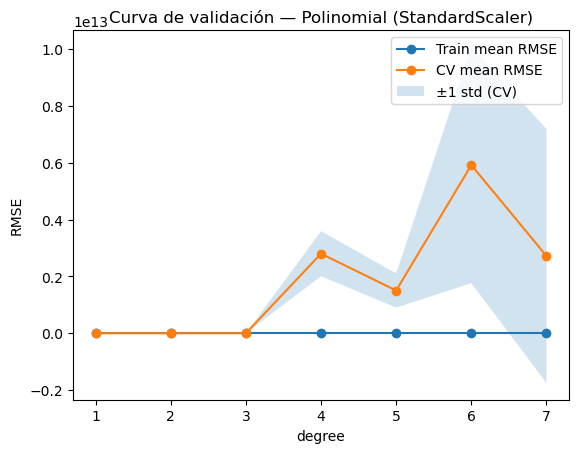

In [12]:
# Gráfica train vs CV
x = val_df["degree"].values
train_rmse = val_df["train_RMSE_mean"].values
cv_rmse = val_df["cv_RMSE_mean"].values
cv_std = val_df["cv_RMSE_std"].values

fig = plt.figure()
ax = fig.add_subplot(111)
ax.set_title("Curva de validación — Polinomial (StandardScaler)")
ax.plot(x, train_rmse, marker="o", label="Train mean RMSE")
ax.plot(x, cv_rmse, marker="o", label="CV mean RMSE")
ax.fill_between(x, cv_rmse - cv_std, cv_rmse + cv_std, alpha=0.2, label="±1 std (CV)")
ax.set_xlabel("degree")
ax.set_ylabel("RMSE")
ax.legend()
plt.show()

## Actividad 3 — Regresión regularizada: Ridge y Lasso (GridSearchCV)

In [13]:
alphas = np.logspace(-4, 3, 25)

# Ridge
ridge_pipe = Pipeline([
    ("preprocess", build_preprocess_no_poly(X_train, scaler_numeric=StandardScaler())),
    ("reg", Ridge(random_state=RANDOM_STATE)),
])

param_grid_ridge = {
    "preprocess": [
        build_preprocess_no_poly(X_train, scaler_numeric=StandardScaler()),
        build_preprocess_no_poly(X_train, scaler_numeric=MinMaxScaler()),
        build_preprocess_no_poly(X_train, scaler_numeric="passthrough"),
    ],
    "reg__alpha": alphas
}

gs_ridge = GridSearchCV(
    ridge_pipe, param_grid=param_grid_ridge, scoring=scoring, refit="RMSE", cv=cv, n_jobs=-1
)
gs_ridge.fit(X_train, y_train)

print("Mejor Ridge — neg RMSE:", gs_ridge.best_score_)
print("Best params:", gs_ridge.best_params_)

Mejor Ridge — neg RMSE: -10.562156930224747
Best params: {'preprocess': ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['Age', 'Weight (kg)', 'Height (m)', 'BMI',
                                  'Abdominal Circumference (cm)',
                                  'Total Cholesterol (mg/dL)', 'HDL (mg/dL)',
                                  'Fasting Blood Sugar (mg/dL)', 'Height (cm)',
                                  'Waist-to-Height Ratio', 'Systolic BP',
                                  'Diastolic BP', 'Estimated LDL (mg/dL)']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                

In [14]:
res_ridge = pd.DataFrame(gs_ridge.cv_results_).copy()
res_ridge["mean_test_RMSE"] = -res_ridge["mean_test_RMSE"]
res_ridge["mean_test_MAE"]  = -res_ridge["mean_test_MAE"]

cols = ["mean_test_RMSE","std_test_RMSE","mean_test_MAE","std_test_MAE","mean_test_R2","std_test_R2","rank_test_RMSE","params"]
display(res_ridge[cols].sort_values("mean_test_RMSE").head(10))

best_ridge = gs_ridge.best_estimator_
pred_ridge_test = best_ridge.predict(X_test)
print("TEST metrics (Ridge):", metrics(y_test, pred_ridge_test))

,mean_test_RMSE,std_test_RMSE,mean_test_MAE,std_test_MAE,mean_test_R2,std_test_R2,rank_test_RMSE,params
21,10.562157,1.923730,3.531758,0.256230,0.028090,0.018882,1,{'preprocess': ColumnTransformer(transformers=...
22,10.567075,1.926401,3.485642,0.271381,0.027258,0.017003,2,{'preprocess': ColumnTransformer(transformers=...
44,10.567784,1.854538,3.752901,0.265199,0.024329,0.011990,3,{'preprocess': ColumnTransformer(transformers=...
20,10.568307,1.917034,3.607328,0.248249,0.026658,0.019713,4,{'preprocess': ColumnTransformer(transformers=...
43,10.569222,1.859188,3.744211,0.249389,0.024237,0.013815,5,{'preprocess': ColumnTransformer(transformers=...
45,10.571464,1.855751,3.764050,0.285829,0.023684,0.009955,6,{'preprocess': ColumnTransformer(transformers=...
42,10.574179,1.867929,3.748072,0.246080,0.023640,0.015586,7,{'preprocess': ColumnTransformer(transformers=...
71,10.574423,1.935743,3.583439,0.254931,0.026166,0.021847,8,{'preprocess': ColumnTransformer(transformers=...
70,10.576372,1.923260,3.641089,0.244330,0.025330,0.020944,9,{'preprocess': ColumnTransformer(transformers=...
19,10.579031,1.909629,3.685987,0.243657,0.024328,0.020015,10,{'preprocess': ColumnTransformer(transformers=...


TEST metrics (Ridge): {'RMSE': 10.617750616706159, 'MAE': 3.525933700348329, 'R2': 0.03152028168809917}


In [15]:
# Lasso
lasso_pipe = Pipeline([
    ("preprocess", build_preprocess_no_poly(X_train, scaler_numeric=StandardScaler())),
    ("reg", Lasso(max_iter=20000, random_state=RANDOM_STATE)),
])

param_grid_lasso = {
    "preprocess": [
        build_preprocess_no_poly(X_train, scaler_numeric=StandardScaler()),
        build_preprocess_no_poly(X_train, scaler_numeric=MinMaxScaler()),
        build_preprocess_no_poly(X_train, scaler_numeric="passthrough"),
    ],
    "reg__alpha": alphas
}

gs_lasso = GridSearchCV(
    lasso_pipe, param_grid=param_grid_lasso, scoring=scoring, refit="RMSE", cv=cv, n_jobs=-1
)
gs_lasso.fit(X_train, y_train)

print("Mejor Lasso — neg RMSE:", gs_lasso.best_score_)
print("Best params:", gs_lasso.best_params_)

Mejor Lasso — neg RMSE: -10.526444972988537
Best params: {'preprocess': ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', MinMaxScaler())]),
                                 ['Age', 'Weight (kg)', 'Height (m)', 'BMI',
                                  'Abdominal Circumference (cm)',
                                  'Total Cholesterol (mg/dL)', 'HDL (mg/dL)',
                                  'Fasting Blood Sugar (mg/dL)', 'Height (cm)',
                                  'Waist-to-Height Ratio', 'Systolic BP',
                                  'Diastolic BP', 'Estimated LDL (mg/dL)']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                  

In [16]:
res_lasso = pd.DataFrame(gs_lasso.cv_results_).copy()
res_lasso["mean_test_RMSE"] = -res_lasso["mean_test_RMSE"]
res_lasso["mean_test_MAE"]  = -res_lasso["mean_test_MAE"]

cols = ["mean_test_RMSE","std_test_RMSE","mean_test_MAE","std_test_MAE","mean_test_R2","std_test_R2","rank_test_RMSE","params"]
display(res_lasso[cols].sort_values("mean_test_RMSE").head(10))

best_lasso = gs_lasso.best_estimator_
pred_lasso_test = best_lasso.predict(X_test)
print("TEST metrics (Lasso):", metrics(y_test, pred_lasso_test))

,mean_test_RMSE,std_test_RMSE,mean_test_MAE,std_test_MAE,mean_test_R2,std_test_R2,rank_test_RMSE,params
35,10.526445,1.875307,3.711162,0.253562,0.033039,0.012033,1,{'preprocess': ColumnTransformer(transformers=...
11,10.531997,1.950991,3.483478,0.255359,0.034839,0.024336,2,{'preprocess': ColumnTransformer(transformers=...
34,10.534289,1.880675,3.682700,0.242539,0.031706,0.016318,3,{'preprocess': ColumnTransformer(transformers=...
10,10.544463,1.930326,3.602203,0.242782,0.031665,0.022976,4,{'preprocess': ColumnTransformer(transformers=...
12,10.544834,1.965191,3.409009,0.286324,0.033022,0.024069,5,{'preprocess': ColumnTransformer(transformers=...
33,10.552070,1.890914,3.713404,0.246069,0.028711,0.018694,6,{'preprocess': ColumnTransformer(transformers=...
36,10.564336,1.874765,3.798483,0.308393,0.025842,0.005540,7,{'preprocess': ColumnTransformer(transformers=...
61,10.565171,1.969273,3.542259,0.255414,0.029133,0.028054,8,{'preprocess': ColumnTransformer(transformers=...
9,10.565908,1.911811,3.699161,0.236405,0.026867,0.021667,9,{'preprocess': ColumnTransformer(transformers=...
60,10.566955,1.935488,3.647466,0.235564,0.027523,0.023968,10,{'preprocess': ColumnTransformer(transformers=...


TEST metrics (Lasso): {'RMSE': 10.564361533725382, 'MAE': 3.656075130661087, 'R2': 0.041235380304697644}


### Actividad 3 — Variables llevadas a cero por Lasso (selección automática)

In [17]:
# Para recuperar nombres de features después del preprocesamiento (OneHot), se requiere sklearn>=1.0
# Intentamos extraer; si falla por versión, al menos reportamos coeficientes no-cero por índice.

try:
    pre = best_lasso.named_steps["preprocess"]
    feature_names = pre.get_feature_names_out()
    coefs = best_lasso.named_steps["reg"].coef_
    coef_s = pd.Series(coefs, index=feature_names).sort_values(key=np.abs, ascending=False)
    display(coef_s.head(30))
    print("N coeficientes exactamente cero:", int((coef_s == 0).sum()), "/", len(coef_s))
except Exception as e:
    print("No fue posible extraer nombres de features (versión sklearn). Error:", e)
    coefs = best_lasso.named_steps["reg"].coef_
    print("Coeficientes (primeros 30):", coefs[:30])

num__BMI                                             5.030293
cat__Blood Pressure Category_Normal                 -2.853435
cat__Diabetes Status_Y                               2.202846
cat__Family History of CVD_Y                        -0.974624
cat__Physical Activity Level_Low                    -0.623894
cat__Physical Activity Level_Moderate                0.366196
cat__Smoking Status_Y                                0.321974
num__Systolic BP                                     0.296010
num__Estimated LDL (mg/dL)                           0.000000
cat__Blood Pressure Category_Hypertension Stage 2    0.000000
cat__Blood Pressure Category_Hypertension Stage 1    0.000000
cat__Sex_M                                          -0.000000
num__Age                                            -0.000000
num__Weight (kg)                                    -0.000000
num__Waist-to-Height Ratio                          -0.000000
num__Height (cm)                                    -0.000000
num__Fas

N coeficientes exactamente cero: 14 / 22


## Actividad 4 — Regresión polinomial regularizada (Polinomial + Ridge)

In [18]:
poly_ridge_pipe = Pipeline([
    ("preprocess", build_preprocess_with_poly(X_train, scaler_numeric=StandardScaler(), degree=2)),
    ("reg", Ridge(random_state=RANDOM_STATE)),
])

degrees = [1,2,3,4,5]
alphas_pr = np.logspace(-4, 3, 15)

preprocess_candidates = []
for sc in [StandardScaler(), MinMaxScaler(), "passthrough"]:
    for d in degrees:
        preprocess_candidates.append(build_preprocess_with_poly(X_train, scaler_numeric=sc, degree=d))

param_grid_poly_ridge = {
    "preprocess": preprocess_candidates,
    "reg__alpha": alphas_pr
}

gs_poly_ridge = GridSearchCV(
    poly_ridge_pipe, param_grid=param_grid_poly_ridge, scoring=scoring, refit="RMSE", cv=cv, n_jobs=-1
)
gs_poly_ridge.fit(X_train, y_train)

print("Mejor Polinomial+Ridge — neg RMSE:", gs_poly_ridge.best_score_)
print("Best params:", gs_poly_ridge.best_params_)

Mejor Polinomial+Ridge — neg RMSE: -10.559004141301484
Best params: {'preprocess': ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', MinMaxScaler()),
                                                 ('poly',
                                                  PolynomialFeatures(degree=3,
                                                                     include_bias=False))]),
                                 ['Age', 'Weight (kg)', 'Height (m)', 'BMI',
                                  'Abdominal Circumference (cm)',
                                  'Total Cholesterol (mg/dL)', 'HDL (mg/dL)',
                                  'Fasting Blood Sugar (mg/dL)', 'Height (cm)',
                                  'Waist-to-Height Ratio', 'Systolic BP',
                                  'Diastolic BP',

In [19]:
res_poly_ridge = pd.DataFrame(gs_poly_ridge.cv_results_).copy()
res_poly_ridge["mean_test_RMSE"] = -res_poly_ridge["mean_test_RMSE"]
res_poly_ridge["mean_test_MAE"]  = -res_poly_ridge["mean_test_MAE"]

cols = ["mean_test_RMSE","std_test_RMSE","mean_test_MAE","std_test_MAE","mean_test_R2","std_test_R2","rank_test_RMSE","params"]
display(res_poly_ridge[cols].sort_values("mean_test_RMSE").head(10))

best_poly_ridge = gs_poly_ridge.best_estimator_
pred_poly_ridge_test = best_poly_ridge.predict(X_test)
print("TEST metrics (Polinomial+Ridge):", metrics(y_test, pred_poly_ridge_test))

,mean_test_RMSE,std_test_RMSE,mean_test_MAE,std_test_MAE,mean_test_R2,std_test_R2,rank_test_RMSE,params
117,10.559004,1.913981,3.534112,0.266656,0.028411,0.014026,1,{'preprocess': ColumnTransformer(transformers=...
132,10.560932,1.928751,3.548219,0.282538,0.028665,0.015663,2,{'preprocess': ColumnTransformer(transformers=...
102,10.562271,1.889639,3.588316,0.265431,0.026781,0.010592,3,{'preprocess': ColumnTransformer(transformers=...
12,10.563780,1.921162,3.561456,0.251475,0.027681,0.019338,4,{'preprocess': ColumnTransformer(transformers=...
101,10.566588,1.891429,3.649021,0.249843,0.026056,0.014379,5,{'preprocess': ColumnTransformer(transformers=...
147,10.566618,1.935615,3.584954,0.290630,0.027849,0.015538,6,{'preprocess': ColumnTransformer(transformers=...
86,10.567723,1.854856,3.751525,0.262113,0.024352,0.012259,7,{'preprocess': ColumnTransformer(transformers=...
13,10.570984,1.926088,3.482088,0.277297,0.026500,0.016235,8,{'preprocess': ColumnTransformer(transformers=...
116,10.572063,1.910824,3.667179,0.267800,0.025840,0.014776,9,{'preprocess': ColumnTransformer(transformers=...
85,10.573303,1.866554,3.746435,0.245753,0.023752,0.015336,10,{'preprocess': ColumnTransformer(transformers=...


TEST metrics (Polinomial+Ridge): {'RMSE': 10.603744770086156, 'MAE': 3.5134009019596952, 'R2': 0.034073634561200494}


## Actividad 5 — Comparación y selección del mejor modelo (promedio + estabilidad)

In [20]:
def best_row(gs: GridSearchCV) -> pd.Series:
    df = pd.DataFrame(gs.cv_results_)
    idx = gs.best_index_
    return df.loc[idx]

def summarize_model(name: str, gs: GridSearchCV) -> dict:
    r = best_row(gs)
    return {
        "Modelo": name,
        "BestParams": gs.best_params_,
        "CV_RMSE_mean": -r["mean_test_RMSE"],
        "CV_RMSE_std": r["std_test_RMSE"],
        "CV_MAE_mean": -r["mean_test_MAE"],
        "CV_MAE_std": r["std_test_MAE"],
        "CV_R2_mean": r["mean_test_R2"],
        "CV_R2_std": r["std_test_R2"],
    }

compare = pd.DataFrame([
    summarize_model("Polinomial", gs_poly),
    summarize_model("Ridge", gs_ridge),
    summarize_model("Lasso", gs_lasso),
    summarize_model("Polinomial+Ridge", gs_poly_ridge),
]).sort_values("CV_RMSE_mean").reset_index(drop=True)

display(compare)

,Modelo,BestParams,CV_RMSE_mean,CV_RMSE_std,CV_MAE_mean,CV_MAE_std,CV_R2_mean,CV_R2_std
0,Lasso,{'preprocess': ColumnTransformer(transformers=...,10.526445,1.875307,3.711162,0.253562,0.033039,0.012033
1,Polinomial+Ridge,{'preprocess': ColumnTransformer(transformers=...,10.559004,1.913981,3.534112,0.266656,0.028411,0.014026
2,Ridge,{'preprocess': ColumnTransformer(transformers=...,10.562157,1.923730,3.531758,0.256230,0.028090,0.018882
3,Polinomial,{'preprocess': ColumnTransformer(transformers=...,10.607325,1.895648,3.841081,0.248419,0.018400,0.020583


El modelo Lasso fue seleccionado como modelo final debido a que obtuvo el menor RMSE promedio en validación cruzada. Adicionalmente, presenta una desviación estándar reducida, lo que sugiere estabilidad en el desempeño entre los distintos folds. El resultado en el conjunto de test es consistente con el desempeño observado en validación cruzada, lo que indica buena capacidad de generalización.

## Actividad 6 — Intervalos de confianza (bootstrap en TEST, >= 500 remuestreos)

Modelo final: Lasso
Métricas puntuales en TEST: {'RMSE': 10.564361533725382, 'MAE': 3.656075130661087, 'R2': 0.041235380304697644}


,mean,ci_95_lower,ci_95_upper
RMSE,10.368703,6.429557,14.602865
MAE,3.636031,2.741541,4.865587
R2,0.041638,0.013735,0.080326


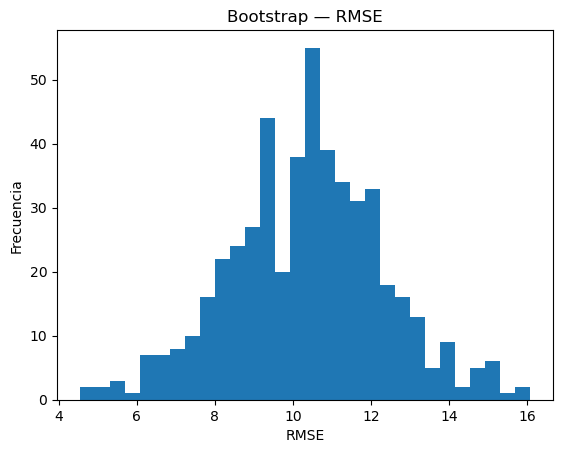

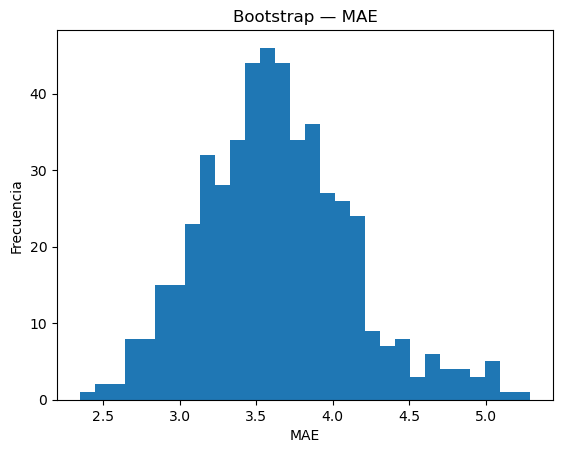

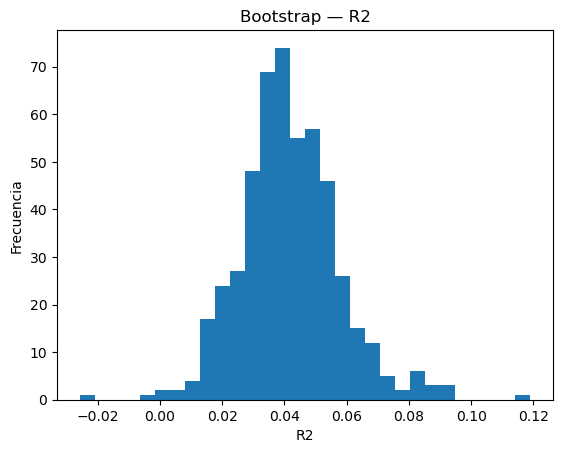

In [21]:
def bootstrap_ci(model, X_test: pd.DataFrame, y_test: pd.Series, n_boot: int = 500, ci: float = 0.95):
    rng = np.random.default_rng(RANDOM_STATE)
    n = len(y_test)
    rows = []

    for _ in range(n_boot):
        idx = rng.integers(0, n, size=n)
        Xb = X_test.iloc[idx]
        yb = y_test.iloc[idx]
        pred = model.predict(Xb)
        rows.append(metrics(yb, pred))

    df_samp = pd.DataFrame(rows)
    alpha = (1 - ci) / 2
    out = pd.DataFrame({
        "mean": df_samp.mean(),
        f"ci_{int(ci*100)}_lower": df_samp.quantile(alpha),
        f"ci_{int(ci*100)}_upper": df_samp.quantile(1 - alpha),
    })
    return df_samp, out

def plot_bootstrap(df_samp: pd.DataFrame, bins: int = 30):
    for col in df_samp.columns:
        fig = plt.figure()
        ax = fig.add_subplot(111)
        ax.set_title(f"Bootstrap — {col}")
        ax.hist(df_samp[col].values, bins=bins)
        ax.set_xlabel(col)
        ax.set_ylabel("Frecuencia")
        plt.show()

# Selección automática: tomamos el mejor por CV_RMSE_mean (puedes cambiarlo si argumentas otra cosa)
best_name = compare.iloc[0]["Modelo"]
model_map = {
    "Polinomial": gs_poly.best_estimator_,
    "Ridge": gs_ridge.best_estimator_,
    "Lasso": gs_lasso.best_estimator_,
    "Polinomial+Ridge": gs_poly_ridge.best_estimator_,
}
final_model = model_map[best_name]

# Reentrenar en todo X_train para bootstrap sobre TEST congelado
final_model.fit(X_train, y_train)
test_pred = final_model.predict(X_test)
print("Modelo final:", best_name)
print("Métricas puntuales en TEST:", metrics(y_test, test_pred))

df_samp, df_ci = bootstrap_ci(final_model, X_test, y_test, n_boot=500, ci=0.95)
display(df_ci)
plot_bootstrap(df_samp, bins=30)

## Actividad 7 — Análisis de resultados (responder preguntas del enunciado)

### 7.1 Análisis cuantitativo
Responde con evidencia (tablas/gráficas) y con interpretación:
- ¿Cuál modelo obtuvo el mejor desempeño en test?
- ¿Coincide el mejor desempeño en test con el mejor promedio en validación cruzada? Si no coincide, ¿por qué?
- ¿El modelo con mejor promedio es necesariamente el más adecuado? Discute la desviación estándar.
- Con base en la curva de validación: ¿en qué grado empieza el sobreajuste?
- ¿Cómo afecta la regularización la magnitud y estabilidad de los coeficientes?
- ¿Los IC de bootstrap sugieren estabilidad o alta variabilidad?

### 7.2 Análisis cualitativo
- ¿Qué variables quedaron “seleccionadas” por Lasso (coeficientes no cero)?
- Interpretación práctica de coeficientes del modelo final.
- ¿Hay diferencias entre el modelo más preciso y el más interpretable?
- ¿Qué decisiones estratégicas podría tomar AlpesHearth con estos resultados?

### 7.3 Reflexión conceptual
- Relación complejidad–generalización–estabilidad.
- Fuentes de sesgo potenciales (datos + modelado).
- Si el tamaño de muestra fuera mayor: ¿esperas cambios en estabilidad y por qué?

## Sección obligatoria — Uso de herramientas de IA generativa

Incluye:
1) herramienta y para qué la usaste,  
2) prompts principales,  
3) evaluación crítica (errores/limitaciones/correcciones),  
4) aportes propios (qué decidiste tú y por qué).

## (Opcional) Exportar predicciones para el archivo de test (si el curso lo requiere)

In [ ]:
# Si necesitas generar un CSV para el test original (mismo formato de separador), usa esto.
# Nota: esto NO es parte explícita del Lab 2, pero lo dejamos por consistencia con Lab 1.

# 1) Entrenar en todo el train limpio (no split) con el modelo final seleccionado
X_full = train.drop(columns=[TARGET] + DROP_ALWAYS, errors="ignore").copy()
y_full = train[TARGET].copy()

final_model.fit(X_full, y_full)

# 2) Preparar X_submit con columnas alineadas
test_submit = clean_common(test_raw.copy(), CAT_COLS)
X_submit = test_submit.drop(columns=DROP_ALWAYS, errors="ignore").copy()
X_submit = X_submit.reindex(columns=X_full.columns)

# 3) Predecir y exportar
out = test_raw.copy()
out[TARGET] = final_model.predict(X_submit)

output_path = "Datos_Test_Lab2_con_pred.csv"
out.to_csv(output_path, index=False, sep=";")
print("Archivo exportado:", output_path)
display(out.head())